# 1. Imports

In [321]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from sklearn.metrics import accuracy_score, recall_score, brier_score_loss, precision_score
from collections import Counter

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

# 2. Load Data

In [ ]:
DB_PATH = "../compliance_audit.db"

conn = sqlite3.connect(DB_PATH)

df = pd.read_sql_query(
    """
    SELECT *
    FROM audited_trades
    """,
    conn
)

print(df.shape)
df.head()

(220, 33)


,trade_id,trade_timestamp,client_age,client_income,risk_tolerance,investment_experience,investment_objective,investment_time_horizon,investment_type,investment_amount,...,primary_policy,compliance_probability,compliance_label,risk_score,confidence_score,escalation_level,priority_score,flag_reasons,retrieved_policies,retrieved_chunks
0,TRADE-c0653af9,2026-06-06 05:47:05.685643,26,86224.0,High,Beginner,Growth,Medium,ETFs,43112.00,...,POL-002-KYC,1.0,1,25.0,0.510,queue,5.00,The investment amount represents 50% of the cl...,"[""POL-004-CONCENTRATION"", ""POL-010-CLIENT-OBJE...","[{""chunk_id"": ""POL-002-KYC_CH_005"", ""policy_id..."
1,TRADE-7d2159b2,2026-06-03 12:30:41.482179,54,173967.0,Low,Intermediate,Preservation,Medium,Stocks,14419.05,...,POL-001-SUITABILITY,0.4,0,40.0,0.735,priority,85.95,The client has a Low risk tolerance and a Capi...,"[""POL-002-KYC"", ""POL-010-CLIENT-OBJECTIVE"", ""P...","[{""chunk_id"": ""POL-004-CONCENTRATION_CH_007"", ..."
2,TRADE-eb48cfaa,2026-05-27 18:23:37.942188,45,179078.0,Low,Advanced,Preservation,Medium,Stocks,29962.33,...,POL-001-SUITABILITY,0.4,0,40.0,0.735,priority,85.95,The client has a Low risk tolerance and an inv...,"[""POL-004-CONCENTRATION"", ""POL-010-CLIENT-OBJE...","[{""chunk_id"": ""POL-004-CONCENTRATION_CH_007"", ..."
3,TRADE-3202b601,2026-05-25 18:37:18.237533,80,94459.0,Low,Intermediate,Preservation,Short,Stocks,47229.50,...,POL-002-KYC,0.4,0,100.0,0.820,urgent,175.40,The client has a Low risk tolerance and a capi...,"[""POL-004-CONCENTRATION"", ""POL-010-CLIENT-OBJE...","[{""chunk_id"": ""POL-004-CONCENTRATION_CH_007"", ..."
4,TRADE-d7664eb0,2026-06-16 13:25:07.275602,75,217215.0,Low,Advanced,Preservation,Medium,Stocks,55207.27,...,POL-001-SUITABILITY,0.4,0,50.0,0.780,priority,91.60,The client has a Low risk tolerance and a capi...,"[""POL-004-CONCENTRATION"", ""POL-010-CLIENT-OBJE...","[{""chunk_id"": ""POL-004-CONCENTRATION_CH_007"", ..."


## 2.1. Condition Data

In [256]:
df["predicted_workflow_bucket"] = df["escalation_level"].map(lambda s: "Auto_pass" if s == "none" else s)
df["predicted_workflow_bucket"] = df["predicted_workflow_bucket"].apply(lambda s: s.upper())

df["expected_workflow_bucket"] = df["expected_workflow_bucket"].apply(lambda s: s.upper())

LIST_COLUMNS = [
    "relevant_policies",
    "retrieved_policies"
]

for col in LIST_COLUMNS:
    df[col] = df[col].apply(ast.literal_eval)

# 3. North Star Metric
### (% cases correctly routed to lowest safe workflow level)

In [257]:
df["correctly_routed"] = (
    df["predicted_workflow_bucket"]
    == 
    df["expected_workflow_bucket"]
)

print(f'Percentage of cases correctly routed to lowest safe workflow level: {df["correctly_routed"].mean()*100:.1f}%')

Percentage of cases correctly routed to lowest safe workflow level: 77.7%


# 3. Product Success Metrics
## 3.1. Compliance Classification Accuracy

In [299]:
compliance_accuracy = accuracy_score(df["true_compliance"], df["compliance_label"])
print(f"Compliance classification accuracy: {(compliance_accuracy*100):.1f}%")

Compliance classification accuracy: 99.5%


## 3.2. Compliance False Negative Rate

In [300]:
non_compliant_df = df[df["true_compliance"]==0]

compliance_fnr = (non_compliant_df["compliance_label"]!=0).mean()

print(f"Compliance False Negative Rate (%): {(compliance_fnr*100):.1f}%")

Compliance False Negative Rate (%): 1.1%


In [291]:
compliance_false_negative_count = (
    (df["true_compliance"] == 0) &
    (df["compliance_label"] == 1)
).sum()

print(f"Compliance False Negative Count: {compliance_false_negative_count}")

Compliance False Negative Count: 1


In [316]:
df[(df["true_compliance"]==0) & (df["compliance_label"]==1)]

,trade_id,trade_timestamp,client_age,client_income,risk_tolerance,investment_experience,investment_objective,investment_time_horizon,investment_type,investment_amount,advisor_id,advisor_experience,advisor_history_risk,advisor_rationale,advisor_notes,kyc_completeness,true_compliance,case_type,scenario_name,difficulty,severity_tier,expected_workflow_bucket,relevant_policies,primary_policy,compliance_probability,compliance_label,risk_score,confidence_score,escalation_level,priority_score,flag_reasons,retrieved_policies,retrieved_chunks,predicted_workflow_bucket,correctly_routed,trust_proxy,interaction_number,compliance_fn,compliance_fp,expected_escalation_rank,predicted_escalation_rank,urgent_underescalated,autopass_overescalated,non_urgent_underescalated,non_urgent_overescalated,assessment_correct
152,TRADE-2c0cb603,2026-06-08 00:21:36.209325,25,54539.0,Medium,Beginner,Growth,Long,Options,6791.17,ADV-014,Senior,Medium,Client requested increased exposure to Options...,Portfolio concentration metrics reviewed as pa...,Uncertain,0,Insufficient Experience,Insufficient Experience,Easy,High,PRIORITY,"[POL-001-SUITABILITY, POL-002-KYC, POL-003-SUR...",POL-002-KYC,1.0,1,10.0,0.565,queue,5.0,The advisor's rationale is generic and fails t...,"[POL-004-CONCENTRATION, POL-010-CLIENT-OBJECTI...","[{""chunk_id"": ""POL-010-CLIENT-OBJECTIVE_CH_002...",QUEUE,False,0.800354,153,True,False,2,1,False,False,True,False,False


## 3.2. "Urgent" Case Recall

In [278]:
urgent_df = df[df["expected_workflow_bucket"]=="URGENT"]
#urgent_recall = (urgent_df["predicted_workflow_bucket"] == urgent_df["expected_workflow_bucket"]).sum()/len(urgent_df)

urgent_recall = recall_score(urgent_df["expected_workflow_bucket"], urgent_df["predicted_workflow_bucket"], pos_label="URGENT")

print(f"Urgent Case Recall: {(urgent_recall*100):.1f}%")

Urgent Case Recall: 66.7%


## 3.3. Unsafe Auto-pass Rate

In [ ]:
autopass_pred_df = df[df["predicted_workflow_bucket"]=="AUTO_PASS"]

unsafe_autopass_rate = (autopass_pred_df["expected_workflow_bucket"]!="AUTO_PASS").mean()

print(f"Unsafe Auto-pass Rate: {unsafe_autopass_rate:.3f}")

Unsafe Auto-pass Rate: 0.051


## 3.4. Workflow Routing Contingency Table

In [261]:
workflow_table = pd.crosstab(df["expected_workflow_bucket"], df["predicted_workflow_bucket"], margins=True)

workflow_table

predicted_workflow_bucket,AUTO_PASS,PRIORITY,QUEUE,URGENT,All
expected_workflow_bucket,,,,,
AUTO_PASS,37,0,26,0,63
PRIORITY,0,59,1,9,69
QUEUE,2,3,59,0,64
URGENT,0,8,0,16,24
All,39,70,86,25,220


In my case workflow design, trades are routed to 1 of 4 categories -- from highest to lowest review priority: "urgent", "priority", "queue", and "auto-pass" ("auto-pass" is the only category treated as not requiring human review). We see in the contingency table that:
- 8 "urgent" cases were under-routed as "priority" cases
- 1 "priority" case was under-routed as a "queue" case
- 2 "queue" cases were under-routed as "auto-pass" cases

## 3.5. Workflow Routing Accuracy

In [281]:
workflow_accuracy = (
    df["expected_workflow_bucket"]
    ==
    df["predicted_workflow_bucket"]
).mean()

print(f"Workflow Accuracy: {workflow_accuracy:.3f}")

Workflow Accuracy: 0.777


## 3.6. Auto-pass Over-escalating

In [279]:
autopass_expect_df = df[df["expected_workflow_bucket"]=="AUTO_PASS"]

ap_overescalated = (autopass_expect_df["predicted_workflow_bucket"] != "AUTO_PASS").mean()

print(f"Auto-pass over-escalation: {(ap_overescalated*100):.1f}%")

Auto-pass over-escalation: 41.3%


## 3.7. Escalation (to human review) Precision

In [294]:
predicted_escalated = df["predicted_workflow_bucket"] != "AUTO_PASS"

expected_escalated = df["expected_workflow_bucket"] != "AUTO_PASS"

escalation_precision = (predicted_escalated & expected_escalated).sum() / predicted_escalated.sum()

print(f"'Human-review needed' prediction precision: {(escalation_precision*100):.1f}%")

'Human-review needed' prediction precision: 85.6%


## 3.7. Simulated Reviewer Trust Proxy

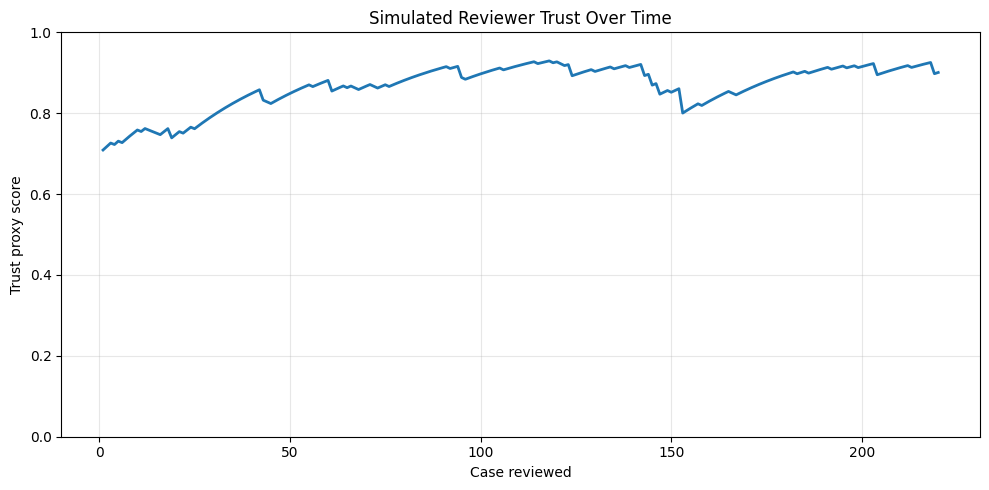

Initial trust proxy: 0.700
Final trust proxy: 0.901
Minimum trust proxy: 0.709
Maximum trust proxy: 0.929
Mean trust proxy: 0.866
Net trust change: +0.201


In [298]:
trust = 0.7
trust_history = []

ROUTE_ORDER = {
    "AUTO_PASS": 0,
    "NONE": 0,
    "QUEUE": 1,
    "PRIORITY": 2,
    "URGENT": 3,
}

def classify_routing(row):
    expected = ROUTE_ORDER[row.expected_workflow_bucket]
    predicted = ROUTE_ORDER[row.predicted_workflow_bucket]

    if predicted == expected:
        return "routing_correct"
    elif predicted > expected:
        return "over_escalated"
    else:
        return "under_escalated"
    
def trust_delta(row):
    assessment_correct = (
        row.compliance_label == row.true_compliance
    )

    routing_outcome = classify_routing(row)

    if assessment_correct:
        assessment_outcome = "assessment_correct"
    else:
        assessment_outcome = "assessment_incorrect"

    trust_delta_map = {
        ("assessment_correct", "routing_correct"): 0.030,
        ("assessment_correct", "over_escalated"): -0.005,
        ("assessment_correct", "under_escalated"): -0.030,

        ("assessment_incorrect", "routing_correct"): -0.005,
        ("assessment_incorrect", "over_escalated"): -0.025,
        ("assessment_incorrect", "under_escalated"): -0.070,
    }

    delta = trust_delta_map[(assessment_outcome, routing_outcome)]

    if not assessment_correct and row.confidence_score >= 0.8:
        delta -= 0.060

    if assessment_correct and row.confidence_score <= 0.4:
        delta -= 0.015

    return delta

# Generate trust proxy data
for row in df.itertuples():
    delta = trust_delta(row)
    if delta >= 0:
        trust = trust + delta * (1 - trust)
    else:
        trust = trust + delta * trust
    trust = max(0, min(1.0, trust))
    trust_history.append(trust)

df["trust_proxy"] = trust_history

# Plot trust proxy data
# Make an explicit x-axis so the chart is easy to explain.
df = df.reset_index(drop=True)
df["interaction_number"] = df.index + 1

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    df["interaction_number"],
    df["trust_proxy"],
    linewidth=2
)

ax.set_title("Simulated Reviewer Trust Over Time")
ax.set_xlabel("Case reviewed")
ax.set_ylabel("Trust proxy score")
ax.set_ylim(0, 1)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save plot to a PNG file
fig.savefig(
    "trust_proxy_over_time.png",
    dpi=200,
    bbox_inches="tight"
)

print(f"Initial trust proxy: {0.7:.3f}")
print(f"Final trust proxy: {df['trust_proxy'].iloc[-1]:.3f}")
print(f"Minimum trust proxy: {df['trust_proxy'].min():.3f}")
print(f"Maximum trust proxy: {df['trust_proxy'].max():.3f}")
print(f"Mean trust proxy: {df['trust_proxy'].mean():.3f}")
print(f"Net trust change: {df['trust_proxy'].iloc[-1] - 0.7:+.3f}")

A net increase in the trust proxy score over the chronological sequence of timestamped randomly generated cases is observed, although it's noted that trust evolution depends on the case sequence order.  

## 3.8. Failure Mode Analysis

In [265]:
df["compliance_fn"] = ((df["true_compliance"] == 0) & (df["compliance_label"]==1))
df["compliance_fp"] = ((df["true_compliance"] == 1) & (df["compliance_label"]==0))

df["expected_escalation_rank"] = df["expected_workflow_bucket"].map(ROUTE_ORDER)
df["predicted_escalation_rank"] = df["predicted_workflow_bucket"].map(ROUTE_ORDER)

df["urgent_underescalated"] = ((df["expected_workflow_bucket"] == "URGENT") & (df["predicted_escalation_rank"] < ROUTE_ORDER["URGENT"]))
df["autopass_overescalated"] = ((df["expected_workflow_bucket"] == "AUTO_PASS") & (df["predicted_escalation_rank"] > ROUTE_ORDER["AUTO_PASS"]))
df["non_urgent_underescalated"] = ((df["expected_workflow_bucket"] != "URGENT") & (df["predicted_escalation_rank"] < df["expected_escalation_rank"]))
df["non_urgent_overescalated"] = ((df["expected_workflow_bucket"] != "URGENT") & (df["predicted_escalation_rank"] > df["expected_escalation_rank"]))

failure_columns = [
    "compliance_fn",
    "compliance_fp",
    "urgent_underescalated",
    "autopass_overescalated",
    "non_urgent_underescalated",
    "non_urgent_overescalated",
]

failure_records = (
    df.melt(
        id_vars=["trade_id", "scenario_name"],
        value_vars=failure_columns,
        var_name="failure_mode",
        value_name="is_failure",
    )
    .query("is_failure")
    .drop(columns="is_failure")
)

failure_summary = (
    failure_records
    .groupby(["scenario_name", "failure_mode"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

failure_summary

,scenario_name,failure_mode,count
1,Aligned Recommendation,autopass_overescalated,10
2,Aligned Recommendation,non_urgent_overescalated,10
6,High Risk Advisor,autopass_overescalated,9
7,High Risk Advisor,non_urgent_overescalated,9
5,Conflicting Signals,non_urgent_overescalated,7
4,Conflicting Signals,autopass_overescalated,7
14,Risk Signal,non_urgent_overescalated,6
13,Retiree Options,urgent_underescalated,5
10,Insufficient Experience,urgent_underescalated,3
11,KYC Missing,non_urgent_overescalated,3


# 4. RAG / System Diagnostic Metrics

## 4.1. Top Retrieved Policies

In [266]:
policy_counter = Counter()

for policies in df["retrieved_policies"]:
    for policy in policies:
        policy_counter[policy] += 1

policy_freq = pd.DataFrame(
    policy_counter.items(),
    columns=["policy_id", "retrieval_count"]
).sort_values("retrieval_count", ascending=False)

policy_freq["retrieval_rate"] = policy_freq["retrieval_count"] / len(df)

policy_freq

,policy_id,retrieval_count,retrieval_rate
1,POL-010-CLIENT-OBJECTIVE,220,1.000000
4,POL-002-KYC,220,1.000000
0,POL-004-CONCENTRATION,215,0.977273
3,POL-005-SENIOR-VULNERABLE-CLIENTS,210,0.954545
2,POL-006-HIGH-RISK-PRODUCTS,158,0.718182
5,POL-001-SUITABILITY,72,0.327273


## 4.2. Retrieval Recall by Policy

In [267]:
policy_list = set()

for policies in df["relevant_policies"]:
    for policy in policies:
        policy_list.add(policy)

recall_by_policy = {}

for policy in policy_list:
    relevant_mask = df.relevant_policies.apply(lambda x: policy in x)
    relevant_df = df[relevant_mask]
    retrieved_mask = relevant_df.retrieved_policies.apply(lambda x: policy in x)
    retrieved_df = relevant_df[retrieved_mask]
    recall_by_policy[policy] = len(retrieved_df)/len(relevant_df)


recall_by_policy


{'POL-004-CONCENTRATION': 1.0,
 'POL-007-DOCUMENTATION-STANDARDS': 0.0,
 'POL-003-SURVEILLANCE': 0.0,
 'POL-006-HIGH-RISK-PRODUCTS': 0.2857142857142857,
 'POL-001-SUITABILITY': 0.34710743801652894,
 'POL-010-CLIENT-OBJECTIVE': 1.0,
 'POL-005-SENIOR-VULNERABLE-CLIENTS': 1.0,
 'POL-002-KYC': 1.0}

## 4.3. Precision@k & Recall@k

In [268]:
retrieved_df = df[df["relevant_policies"].apply(len) > 0]

def precision_at_k(row):
    retrieved = set(row["retrieved_policies"])
    relevant = set(row["relevant_policies"])

    if len(retrieved) == 0:
        return 0

    return len(retrieved & relevant) / len(retrieved)

def recall_at_k(row):
    retrieved = set(row["retrieved_policies"])
    relevant = set(row["relevant_policies"])

    if len(relevant) == 0:
        return np.nan

    return len(retrieved & relevant) / len(relevant)

retrieved_df["precision_at_k"] = retrieved_df.apply(precision_at_k, axis=1)
retrieved_df["recall_at_k"] = retrieved_df.apply(recall_at_k, axis=1)

print(f"Precision@k: {retrieved_df['precision_at_k'].mean():.3f}")
print(f"Recall@k: {retrieved_df['recall_at_k'].mean():.3f}")

Precision@k: 0.352
Recall@k: 0.540


## 4.4. Primary Relevant Policy Recall & Any Relevant Policy Recall

In [285]:
retrieved_df["primary_policy_retrieved"] = retrieved_df.apply(lambda row: row["primary_policy"] in row["retrieved_policies"], axis=1)

def any_relevant_policy_retrieved(row):
    retrieved = set(row["retrieved_policies"])
    relevant = set(row["relevant_policies"])

    return len(retrieved & relevant) > 0

retrieved_df["any_relevant_policy_retrieved"] = retrieved_df.apply(any_relevant_policy_retrieved, axis=1)

primary_policy_recall = retrieved_df["primary_policy_retrieved"].mean()
any_relevant_policy_recall = retrieved_df["any_relevant_policy_retrieved"].mean()

print(f"Primary Policy Recall: {(primary_policy_recall*100):.1f}%")
print(f"Any Relevant Policy Recall: {(any_relevant_policy_recall*100):.1f}%")

Primary Policy Recall: 66.2%
Any Relevant Policy Recall: 89.7%


We see from these results: retrieval usually finds at least some relevant policy context, although it fails to find the most important policy in roughly one-third of applicable cases.

## 4.5. Brier Score

In [270]:
# Measures accuracy of probabilistic predictions
bs = brier_score_loss(df["true_compliance"], df["compliance_probability"])

print(f"Brier Score for Complaince Prediction: {bs:.2f}")

Brier Score for Complaince Prediction: 0.06


## 4.6. Expected Calibration Error

In [295]:
def expected_calibration_error(df, prob_col, label_col, n_bins=10):
    """
    Measures how well predicted compliance probability matches actual compliance frequency across confidence ranges.
    """
    probs = df[prob_col].to_numpy()
    labels = df[label_col].to_numpy()

    bins = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.minimum(np.digitize(probs, bins) - 1, n_bins - 1) # Convert to 0-based bin index

    ece = 0.0
    n = len(probs)

    for b in range(n_bins):
        bin_mask = bin_indices == b
        bin_size = np.sum(bin_mask)

        if bin_size == 0:
            continue  # Avoid division by zero

        bin_probs = probs[bin_mask]
        bin_labels = labels[bin_mask]

        avg_confidence = np.mean(bin_probs)
        avg_accuracy = np.mean(bin_labels)

        weight = bin_size / n
        ece += weight * abs(avg_confidence - avg_accuracy)

    return float(ece)

ece = expected_calibration_error(df, "compliance_probability", "true_compliance")

print(f"Expected Calibration Error: {ece:.2f}")

Expected Calibration Error: 0.14


## 4.6. Overconfidence Rate

In [272]:
df["assessment_correct"] = df["true_compliance"] == df["compliance_label"]

def calculate_overconfidence_by_threshold(
    df: pd.DataFrame,
    confidence_col: str = "confidence_score",
    correctness_col: str = "assessment_correct",
    thresholds: tuple[float, ...] = (0.50, 0.60, 0.70, 0.80, 0.90),
) -> pd.DataFrame:
    """
    Measures how often high-confidence predictions are wrong.
    """
    records = []

    for threshold in thresholds:
        high_confidence = df[confidence_col] >= threshold
        overconfident = high_confidence & ~df[correctness_col]

        denominator = int(high_confidence.sum())
        error_count = int(overconfident.sum())

        records.append({
            "threshold": threshold,
            "high_confidence_count": denominator,
            "overconfident_error_count": error_count,
            "overconfidence_rate": error_count / denominator if denominator > 0 else float("nan"),
        })

    return pd.DataFrame(records)

calculate_overconfidence_by_threshold(df)


,threshold,high_confidence_count,overconfident_error_count,overconfidence_rate
0,0.5,216,1,0.00463
1,0.6,176,0,0.00000
2,0.7,123,0,0.00000
3,0.8,48,0,0.00000
4,0.9,4,0,0.00000


Overconfidence was rare in this evaluation set, although the result is based on very few incorrect classifications (i.e. compliance classification accuracy = 99.5%) and therefore shouldn't be interpreted as evidence of reliable calibration across broader scenarios.

In [322]:
# ---------------------------------------------------------------------

# 2. Calculate route ranks and overlapping diagnostic flags

# ---------------------------------------------------------------------

df["expected_escalation_rank"] = df["expected_workflow_bucket"].map(ROUTE_ORDER)
df["predicted_escalation_rank"] = df["predicted_workflow_bucket"].map(ROUTE_ORDER)

df["compliance_fn"] = (df["true_compliance"] == 0) & (df["compliance_label"] == 1)
df["compliance_fp"] = (df["true_compliance"] == 1) & (df["compliance_label"] == 0)

df["urgent_underescalated"] = (df["expected_workflow_bucket"] == "URGENT") & (df["predicted_escalation_rank"] < ROUTE_ORDER["URGENT"])
df["autopass_overescalated"] = (df["expected_workflow_bucket"] == "AUTO_PASS") & (df["predicted_escalation_rank"] > ROUTE_ORDER["AUTO_PASS"])

# Exclude urgent cases because they are captured by the dedicated urgent-under-routing category.
df["other_workflow_underescalated"] = (df["expected_workflow_bucket"] != "URGENT") & (df["predicted_escalation_rank"] < df["expected_escalation_rank"])

# Exclude auto-pass cases because they are captured by the dedicated auto-pass-over-routing category.
df["other_workflow_overescalated"] = (df["expected_workflow_bucket"] != "AUTO_PASS") & (df["predicted_escalation_rank"] > df["expected_escalation_rank"])

failure_flag_columns = [
    "compliance_fn",
    "compliance_fp",
    "urgent_underescalated",
    "autopass_overescalated",
    "other_workflow_underescalated",
    "other_workflow_overescalated",
]

# ---------------------------------------------------------------------

# 3. Optional overlapping diagnostic summary

#

# A case can appear in more than one row here. Retain this summary for

# detailed technical diagnostics, but do not use it as the public

# "top failure modes" table.

# ---------------------------------------------------------------------

overlapping_failure_summary = (
df[failure_flag_columns]
.sum()
.rename("count")
.reset_index()
.rename(columns={"index": "failure_flag"})
.sort_values("count", ascending=False)
.reset_index(drop=True)
)

print("Overlapping diagnostic failure flags")
display(overlapping_failure_summary)

# ---------------------------------------------------------------------

# 4. Assign one mutually exclusive primary failure mode per case

#

# np.select applies the first matching condition, so the ordering below

# defines the precedence used when a case has multiple failure flags.

# ---------------------------------------------------------------------

primary_failure_conditions = [
    df["compliance_fn"],
    df["urgent_underescalated"],
    df["compliance_fp"],
    df["autopass_overescalated"],
    df["other_workflow_underescalated"],
    df["other_workflow_overescalated"],
]

primary_failure_labels = [
    "Compliance false negative",
    "Urgent under-routing",
    "Compliance false positive",
    "Auto-pass over-routing",
    "Other workflow under-routing",
    "Other workflow over-routing",
]

df["primary_failure_mode"] = np.select(
    primary_failure_conditions,
    primary_failure_labels,
    default="No primary failure",
)

# ---------------------------------------------------------------------

# 5. Overall mutually exclusive primary-failure summary

# ---------------------------------------------------------------------

failed_case_count = (df["primary_failure_mode"] != "No primary failure").sum()

overall_primary_failure_summary = (
    df.loc[df["primary_failure_mode"] != "No primary failure", "primary_failure_mode"]
    .value_counts()
    .rename_axis("primary_failure_mode")
    .reset_index(name="count")
)

overall_primary_failure_summary["percent_of_all_cases"] = (overall_primary_failure_summary["count"] / len(df) * 100)

if failed_case_count > 0:
    overall_primary_failure_summary["percent_of_failed_cases"] = (overall_primary_failure_summary["count"] / failed_case_count * 100)
else:
    overall_primary_failure_summary["percent_of_failed_cases"] = 0.0

overall_primary_failure_summary = overall_primary_failure_summary.sort_values("count", ascending=False).reset_index(drop=True)

print("Mutually exclusive primary failure modes")
display(overall_primary_failure_summary.style.format({"percent_of_all_cases": "{:.1f}%", "percent_of_failed_cases": "{:.1f}%"}))

# ---------------------------------------------------------------------

# 6. Primary failure modes by scenario

# ---------------------------------------------------------------------

scenario_case_counts = df.groupby("scenario_name").size().rename("scenario_case_count").reset_index()

scenario_failure_summary = (
    df.loc[df["primary_failure_mode"] != "No primary failure", ["scenario_name", "primary_failure_mode"]]
    .groupby(["scenario_name", "primary_failure_mode"], as_index=False).size()
    .rename(columns={"size": "count"}).merge(scenario_case_counts, on="scenario_name", how="left")
)

scenario_failure_summary["rate_within_scenario"] = scenario_failure_summary["count"] / scenario_failure_summary["scenario_case_count"] * 100


scenario_failure_summary = scenario_failure_summary.sort_values(["count", "scenario_name"], ascending=[False, True]).reset_index(drop=True)

print("Primary failure modes by scenario")
display(scenario_failure_summary.style.format({"rate_within_scenario": "{:.1f}%"}))

# ---------------------------------------------------------------------

# 7. Routing-transition analysis

#

# This table answers questions such as:

# - How many expected AUTO_PASS cases became QUEUE?

# - How many expected URGENT cases became PRIORITY?

# ---------------------------------------------------------------------

routing_failures = df.loc[df["expected_workflow_bucket"] != df["predicted_workflow_bucket"]].copy()

routing_failures["routing_direction"] = np.select([routing_failures["predicted_escalation_rank"] < routing_failures["expected_escalation_rank"],
                                                   routing_failures["predicted_escalation_rank"] > routing_failures["expected_escalation_rank"]],
                                                   ["Under-routing", "Over-routing"], default="Correct routing"
                                                   )

routing_failures["route_transition"] = (routing_failures["expected_workflow_bucket"] + " \u2192 " + routing_failures["predicted_workflow_bucket"])

expected_route_counts = df.groupby("expected_workflow_bucket").size().rename("expected_route_case_count").reset_index()

route_transition_summary = (
routing_failures
.groupby(
[
"expected_workflow_bucket",
"predicted_workflow_bucket",
"routing_direction",
"route_transition",
],
as_index=False,
)
.size()
.rename(columns={"size": "count"})
.merge(
expected_route_counts,
on="expected_workflow_bucket",
how="left",
)
)

route_transition_summary["rate_within_expected_route"] = (
route_transition_summary["count"]
/ route_transition_summary["expected_route_case_count"]
* 100
)

route_transition_summary = (
route_transition_summary
.sort_values("count", ascending=False)
.reset_index(drop=True)
)

print("Routing failure transitions")
display(
route_transition_summary.style.format(
{"rate_within_expected_route": "{:.1f}%"}
)
)

# ---------------------------------------------------------------------

# 8. Compact top-failure table suitable for README preparation

# ---------------------------------------------------------------------

top_failure_modes = (
overall_primary_failure_summary[
[
"primary_failure_mode",
"count",
"percent_of_all_cases",
]
]
.head(5)
.copy()
)

top_failure_modes["readme_summary"] = (
top_failure_modes["primary_failure_mode"]
+ ": "
+ top_failure_modes["count"].astype(str)
+ " cases ("
+ top_failure_modes["percent_of_all_cases"]
.round(1)
.astype(str)
+ "% of all cases)"
)

print("Top primary failure modes for README")
display(top_failure_modes)


Overlapping diagnostic failure flags


,failure_flag,count
0,autopass_overescalated,26
1,other_workflow_overescalated,12
2,urgent_underescalated,8
3,other_workflow_underescalated,3
4,compliance_fn,1
5,compliance_fp,0


Mutually exclusive primary failure modes


,primary_failure_mode,count,percent_of_all_cases,percent_of_failed_cases
0,Auto-pass over-routing,26,11.8%,53.1%
1,Other workflow over-routing,12,5.5%,24.5%
2,Urgent under-routing,8,3.6%,16.3%
3,Other workflow under-routing,2,0.9%,4.1%
4,Compliance false negative,1,0.5%,2.0%


Primary failure modes by scenario


,scenario_name,primary_failure_mode,count,scenario_case_count,rate_within_scenario
0,Aligned Recommendation,Auto-pass over-routing,10,50,20.0%
1,High Risk Advisor,Auto-pass over-routing,9,10,90.0%
2,Conflicting Signals,Auto-pass over-routing,7,10,70.0%
3,Risk Signal,Other workflow over-routing,6,20,30.0%
4,Retiree Options,Urgent under-routing,5,5,100.0%
5,Insufficient Experience,Urgent under-routing,3,15,20.0%
6,KYC Missing,Other workflow over-routing,3,20,15.0%
7,Aligned Recommendation,Other workflow under-routing,2,50,4.0%
8,Overexposure,Other workflow over-routing,2,15,13.3%
9,Aggressive Horizon,Other workflow over-routing,1,10,10.0%


Routing failure transitions


,expected_workflow_bucket,predicted_workflow_bucket,routing_direction,route_transition,count,expected_route_case_count,rate_within_expected_route
0,AUTO_PASS,QUEUE,Over-routing,AUTO_PASS → QUEUE,26,63,41.3%
1,PRIORITY,URGENT,Over-routing,PRIORITY → URGENT,9,69,13.0%
2,URGENT,PRIORITY,Under-routing,URGENT → PRIORITY,8,24,33.3%
3,QUEUE,PRIORITY,Over-routing,QUEUE → PRIORITY,3,64,4.7%
4,QUEUE,AUTO_PASS,Under-routing,QUEUE → AUTO_PASS,2,64,3.1%
5,PRIORITY,QUEUE,Under-routing,PRIORITY → QUEUE,1,69,1.4%


Top primary failure modes for README


,primary_failure_mode,count,percent_of_all_cases,readme_summary
0,Auto-pass over-routing,26,11.818182,Auto-pass over-routing: 26 cases (11.8% of all cases)
1,Other workflow over-routing,12,5.454545,Other workflow over-routing: 12 cases (5.5% of all cases)
2,Urgent under-routing,8,3.636364,Urgent under-routing: 8 cases (3.6% of all cases)
3,Other workflow under-routing,2,0.909091,Other workflow under-routing: 2 cases (0.9% of all cases)
4,Compliance false negative,1,0.454545,Compliance false negative: 1 cases (0.5% of all cases)
